# P5EN Ring/Simple AllReduce — Overhead Analysis (0x7)

Regenerates the realistic-model overhead calibration (O_net, O_mem, O_round) from the raw
NCCL profiling dump and plots the three evidence figures. The whole parse/fit/assemble/write
pipeline lives in `realistic_model.extraction.build_overhead()`; this notebook only calls it
and plots. It (re)writes `../realistic_model/overhead.json` as a side effect, so it stays in
sync but is fully decoupled from `p5en-allreduce-0x7-realistic.ipynb` (which regenerates the
same JSON independently). Ring / Simple only.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # repo root: realistic_model/ package
from realistic_model import extraction as ex
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- uniform typography ----
FS = 12
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams.update({'font.size': FS, 'axes.titlesize': FS, 'axes.labelsize': FS,
                     'xtick.labelsize': FS, 'ytick.labelsize': FS,
                     'legend.fontsize': FS, 'figure.titlesize': FS})
SIMPLE_COLOR = '#2E86C1'

# ---- regenerate overhead.json from the raw dump, and get every intermediate for plotting ----
# All parse/fit/assemble/write logic lives in realistic_model.extraction.build_overhead();
# this notebook only calls it and plots the evidence. Editing the generation logic there and
# re-running here refreshes overhead.json AND the figures below (decoupled from realistic.ipynb).
_OUT  = 'nccl_allreduce_ring_inter_r-0-0x7.out'
_JSON = '../realistic_model/overhead.json'
_res = ex.build_overhead(_OUT, _JSON)          # writes overhead.json, returns intermediates
params   = _res['params']
param_df = _res['param_df']
onet_eff = _res['onet_eff']
omem_fit = _res['omem_fit']
gmem     = _res['gmem']
oround   = _res['oround']
print(f'Regenerated {_JSON}; {len(param_df)} Simple configs.')
nch_all = sorted(onet_eff.keys())
nch_cmap = {n: plt.cm.viridis(0.15 + 0.7*i/max(1, len(nch_all)-1)) for i, n in enumerate(nch_all)}

Regenerated ../realistic_model/overhead.json; 40 Simple configs.


## Figure 1 — O_net_eff vs chunk size (per nch), two-segment fit
Effective per-chunk exposed network overhead `o_net_eff = o_net / k_eff`. Point = steady-half
mean, bars = p10..p90. Fit: flat plateau below the auto-searched breakpoint, line above.
This fit is `O_NET_EFF_LINFIT[Simple]` in overhead.json.

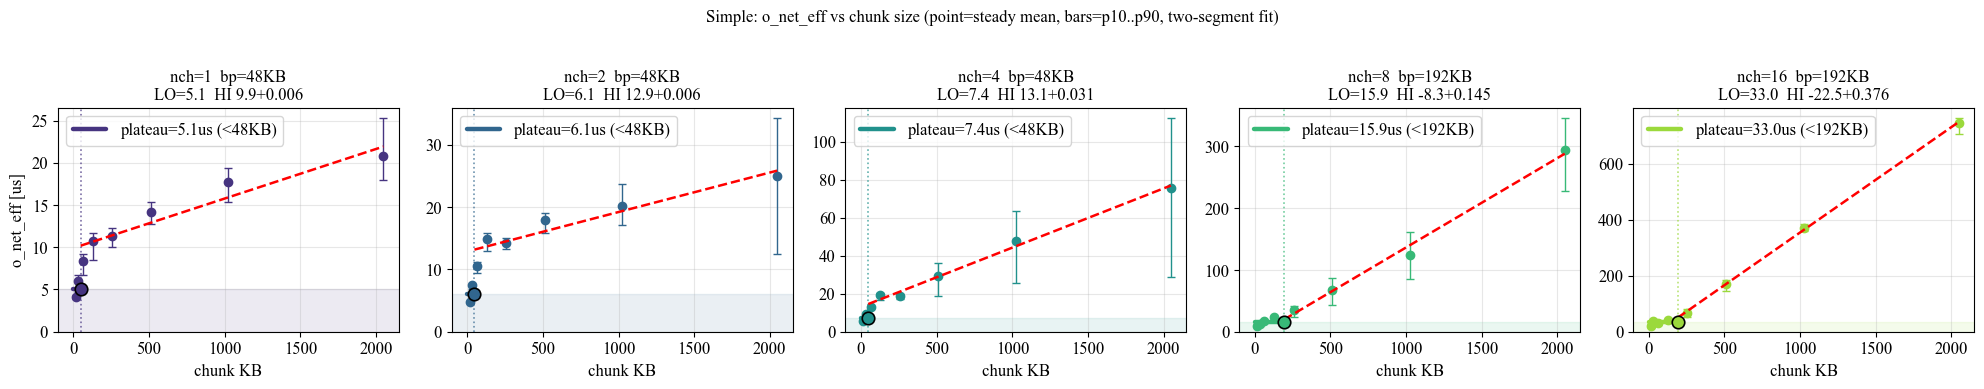

Saved: fig2_onet_eff.png
 nch  breakpoint_KB  lo_const_us  hi_intercept_us  hi_slope_us_per_KB  hi_R2
   1           48.0       5.0889           9.9052            0.005867 0.9078
   2           48.0       6.1072          12.8563            0.006329 0.8929
   4           48.0       7.4270          13.0585            0.031189 0.9928
   8          192.0      15.8668          -8.2628            0.144669 0.9918
  16          192.0      32.9754         -22.4807            0.376263 0.9995


In [2]:
# Figure 1: o_net_eff vs chunk, one panel per nch; measured points + p10..p90 + two-segment fit.
fig, axes = plt.subplots(1, len(nch_all), figsize=(4.0*len(nch_all), 3.8), squeeze=False)
axes = axes[0]
for ax, n in zip(axes, nch_all):
    d = onet_eff[n]
    xs, ys, lo, hi, fit = d['xs'], d['ys'], d['lo'], d['hi'], d['fit']
    ax.errorbar(xs, ys, yerr=[np.clip(ys-lo, 0, None), np.clip(hi-ys, 0, None)],
                fmt='o', color=nch_cmap[n], ms=6, capsize=3, elinewidth=1)
    if fit is not None:
        bp, c = fit['breakpoint_KB'], fit['lo_const_us']
        xmax = xs.max()
        ax.axhspan(0, c, color=nch_cmap[n], alpha=0.10, zorder=0)
        ax.plot([0, bp], [c, c], '-', color=nch_cmap[n], lw=3.2, solid_capstyle='round',
                zorder=4, label=f'plateau={c:.1f}us (<{bp:.0f}KB)')
        ax.plot([bp], [c], 'o', color=nch_cmap[n], ms=9, mec='k', mew=1.2, zorder=6)
        xh = np.linspace(bp, xmax, 30)
        ax.plot(xh, fit['hi_intercept_us'] + fit['hi_slope_us_per_KB']*xh, '--', color='r', lw=1.8, zorder=5)
        ax.axvline(bp, color=nch_cmap[n], ls=':', lw=1.2, alpha=0.7)
        ax.set_title(f'nch={n}  bp={bp:.0f}KB\nLO={c:.1f}  HI {fit["hi_intercept_us"]:.1f}+{fit["hi_slope_us_per_KB"]:.3f}', fontsize=FS)
    ax.axhline(0, color='gray', lw=0.5); ax.set_ylim(0, None); ax.grid(alpha=0.3)
    ax.set_xlabel('chunk KB'); ax.legend(fontsize=FS, loc='upper left')
axes[0].set_ylabel('o_net_eff [us]')
fig.suptitle('Simple: o_net_eff vs chunk size (point=steady mean, bars=p10..p90, two-segment fit)', y=1.02)
plt.tight_layout(); plt.savefig('fig2_onet_eff.png', dpi=140, bbox_inches='tight'); plt.show()
print('Saved: fig2_onet_eff.png')
print(pd.DataFrame([{'nch': n, **onet_eff[n]['fit']} for n in nch_all if onet_eff[n]['fit']]).to_string(index=False))

## Figure 2 — O_mem vs chunk size
Mem-copy time per chunk (union of RECVDONE_TO_DR intervals). Shared-slope linear fit
`O_mem = k*chunk_KB + b` from large chunks; nch 8/16 have a low-chunk plateau. This is
`O_MEM_FIT[Simple]` (and `G_MEM_GBS = 1024/k`).

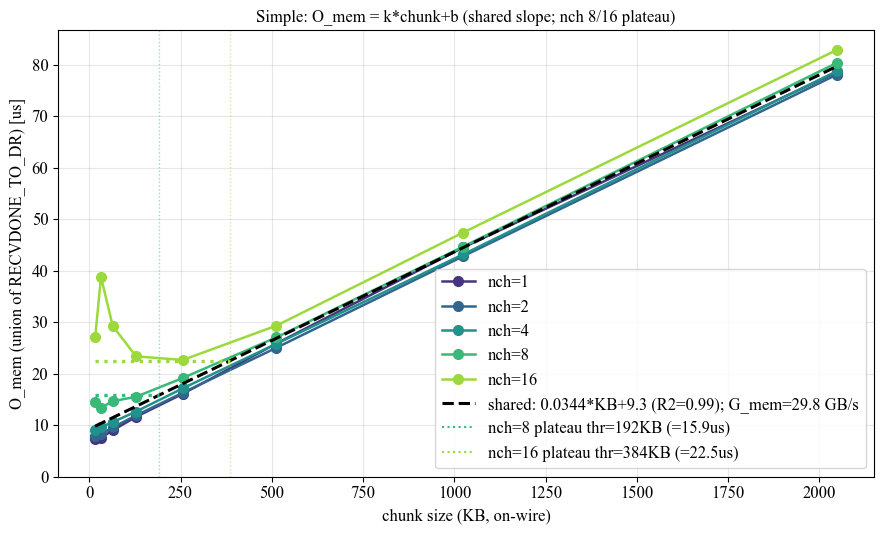

Saved: fig2_Gmem_threads.png
nch         1     2     4     8     16
chunk_KB                              
16.0       7.3   7.9   9.1  14.5  27.1
32.0       7.6   8.3   9.6  13.4  38.8
64.0       9.0   9.6  10.6  14.7  29.3
128.0     11.6  11.9  12.7  15.5  23.4
256.0     16.1  16.3  17.2  19.2  22.7
512.0     25.8  25.0  25.8  27.0  29.3
1024.0    44.5  42.8  43.2  44.7  47.4
2048.0    78.5  78.1  78.7  80.3  82.9


In [3]:
# Figure 2: O_mem vs chunk size (lines per nch) + the shared-slope fit overlay + nch8/16 plateau.
d = param_df.copy()
d['chunk_KB'] = d.buffsize.apply(lambda b: ex.chunk_bytes(b)/1024.0)
nchs = sorted(d.nch.unique())
fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
for n in nchs:
    s = d[d.nch == n].sort_values('chunk_KB')
    if len(s):
        ax.plot(s.chunk_KB, s.O_mem_model_us, 'o-', color=nch_cmap.get(n, 'gray'), ms=7, lw=1.8, label=f'nch={n}')
k, b = omem_fit['k_us_per_KB'], omem_fit['b_us']
xs_line = np.linspace(d.chunk_KB.min(), d.chunk_KB.max(), 100)
ax.plot(xs_line, k*xs_line + b, 'k--', lw=2.2, zorder=5,
        label=f'shared: {k:.4f}*KB+{b:.1f} (R2={omem_fit["R2"]:.2f}); G_mem={gmem:.1f} GB/s')
for n, thr in omem_fit['nch_plateau_thr_KB'].items():
    n = int(n); c = k*thr + b
    ax.hlines(c, d.chunk_KB.min(), thr, color=nch_cmap.get(n, 'gray'), ls=':', lw=2.4, zorder=6)
    ax.axvline(thr, color=nch_cmap.get(n, 'gray'), ls=':', lw=1.0, alpha=0.5)
    ax.plot([], [], ':', color=nch_cmap.get(n, 'gray'), label=f'nch={n} plateau thr={thr:.0f}KB (={c:.1f}us)')
ax.set_xlabel('chunk size (KB, on-wire)'); ax.set_ylabel('O_mem (union of RECVDONE_TO_DR) [us]'); ax.set_ylim(0, None)
ax.set_title('Simple: O_mem = k*chunk+b (shared slope; nch 8/16 plateau)')
ax.legend(fontsize=FS); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('fig2_Gmem_threads.png', dpi=140, bbox_inches='tight'); plt.show()
print('Saved: fig2_Gmem_threads.png')
print(d.pivot_table(index='chunk_KB', columns='nch', values='O_mem_model_us').round(1).to_string())

## Figure 3 — O_round is a real periodic drain (Simple)
O_round excess (raw round-boundary interval minus the steady wire time) is significantly
> 0 and grows with chunk size and nch. Fit `O_round = C + K*(slice_MB*nch)`.

Simple O_round excess: n=40, mean=101.51us, median=48.45us, t=5.32, p_vs_0=1.02e-07
O_round fit: C=42.2211 us, K=40.7095 us/(MB*ch), R2=0.9844


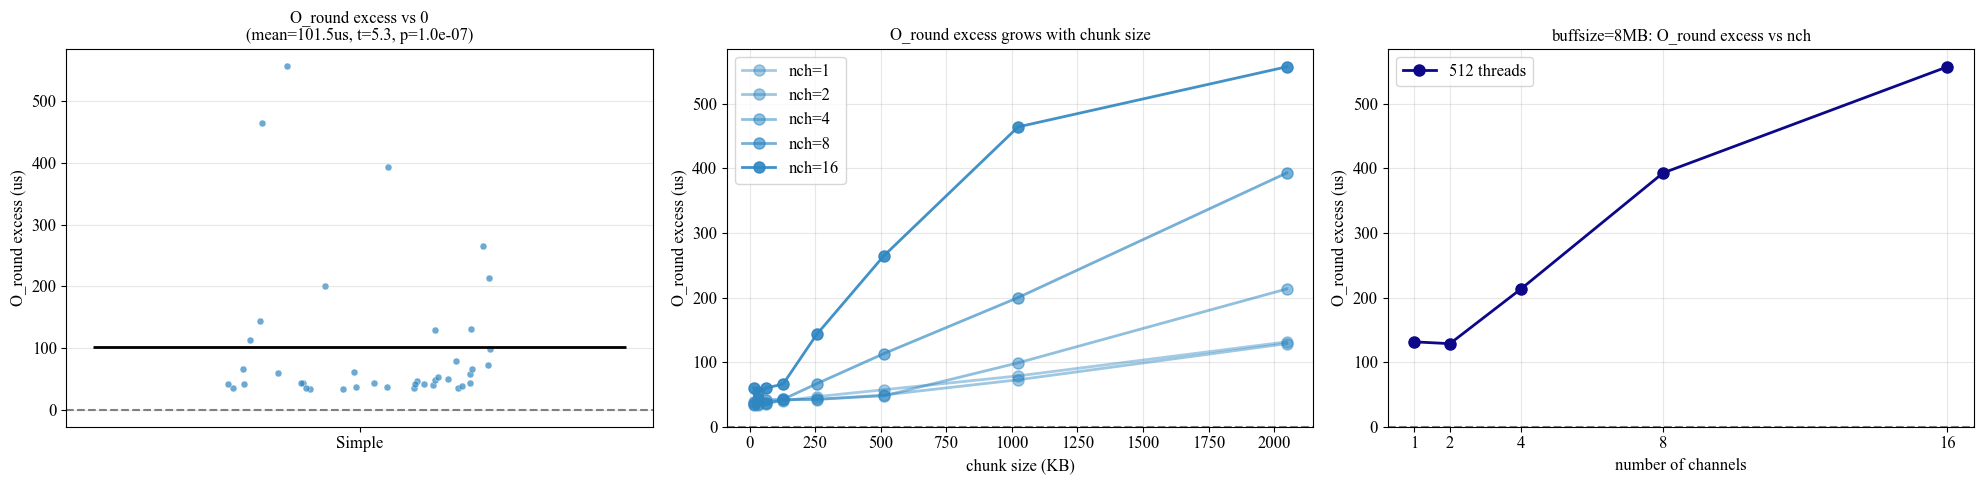

Saved: fig3_Oround.png


In [4]:
# Figure 3: O_round evidence (Simple). Left: excess distribution vs 0 (one-sample t-test).
#   Middle: excess vs chunk size per nch. Right: excess vs nch at buffsize=8MB per nthreads.
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax = axes[0]
v = param_df['O_round_excess_us'].dropna().values
t, n, pval = ex.one_sample_t(v, 0.0)
jit = (np.random.default_rng(9).random(len(v)) - 0.5) * 0.3
ax.scatter(np.zeros(len(v)) + jit, v, color=SIMPLE_COLOR, s=25, alpha=0.7, edgecolor='w', linewidth=0.4)
ax.hlines(v.mean(), -0.3, 0.3, color='k', lw=2)
ax.axhline(0, color='gray', ls='--')
ax.set_xticks([0]); ax.set_xticklabels(['Simple'])
ax.set_ylabel('O_round excess (us)')
ax.set_title(f'O_round excess vs 0\n(mean={v.mean():.1f}us, t={t:.1f}, p={pval:.1e})')
ax.grid(alpha=0.3, axis='y')
print(f'Simple O_round excess: n={n}, mean={v.mean():.2f}us, median={np.median(v):.2f}us, t={t:.2f}, p_vs_0={pval:.2e}')
print(f'O_round fit: C={oround[0]} us, K={oround[1]} us/(MB*ch), R2={oround[2]}')

ax = axes[1]
sim = param_df[param_df.nthreads == 512].copy()
sim['chunk_KB'] = sim.buffsize.apply(lambda b: ex.chunk_bytes(b)/1024.0)
for nch in sorted(sim.nch.unique()):
    dd = sim[sim.nch == nch].dropna(subset=['O_round_excess_us']).sort_values('chunk_KB')
    if len(dd):
        ax.plot(dd.chunk_KB, dd.O_round_excess_us, 'o-', color=SIMPLE_COLOR,
                ms=8, lw=2, alpha=min(1.0, 0.4+0.5*nch/16), label=f'nch={nch}')
ax.axhline(0, color='gray', ls='--')
ax.set_xlabel('chunk size (KB)'); ax.set_ylabel('O_round excess (us)')
ax.set_title('O_round excess grows with chunk size'); ax.legend(fontsize=FS); ax.grid(alpha=0.3); ax.set_ylim(0, None)

ax = axes[2]
sim8 = param_df[param_df.buffsize == '8MB'].dropna(subset=['O_round_excess_us'])
nts = sorted(sim8.nthreads.unique())
nt_cmap = {nt: plt.cm.plasma(i/max(1, len(nts)-1)*0.85) for i, nt in enumerate(nts)}
for nt in nts:
    s = sim8[sim8.nthreads == nt].sort_values('nch')
    if len(s):
        ax.plot(s.nch, s.O_round_excess_us, 'o-', color=nt_cmap[nt], ms=8, lw=2, label=f'{nt} threads')
ax.axhline(0, color='gray', ls='--')
ax.set_xticks(sorted(sim8.nch.unique())); ax.set_xticklabels([int(x) for x in sorted(sim8.nch.unique())])
ax.set_xlabel('number of channels'); ax.set_ylabel('O_round excess (us)')
ax.set_title('buffsize=8MB: O_round excess vs nch'); ax.legend(fontsize=FS); ax.grid(alpha=0.3); ax.set_ylim(0, None)

plt.tight_layout(); plt.savefig('fig3_Oround.png', dpi=140, bbox_inches='tight'); plt.show()
print('Saved: fig3_Oround.png')

## Export overhead.json
Assemble the calibrated Simple-only parameters and write `../realistic_model/overhead.json`.

In [5]:
# overhead.json was (re)written by ex.build_overhead() in the first cell.
import json
print(f'overhead.json (written to {_JSON}):')
print(json.dumps(params, indent=2))

overhead.json (written to ../realistic_model/overhead.json):
{
  "note": "Calibrated from ring_param_extraction (Ring/Simple only). Overhead helpers take SLICE_SIZE (bytes); Simple chunk = buffsize/4. O_net = Iterative recovered-bandwidth gauge, median over chunks; O_NET_EFF_LINFIT = two-segment fit per nch (flat plateau below breakpoint, line above).",
  "STAT": "med",
  "n_configs": 40,
  "O_NET_EFF_LINFIT": {
    "Simple": {
      "1": {
        "breakpoint_KB": 48.0,
        "lo_const_us": 5.0889,
        "hi_intercept_us": 9.9052,
        "hi_slope_us_per_KB": 0.005867,
        "hi_R2": 0.9078
      },
      "2": {
        "breakpoint_KB": 48.0,
        "lo_const_us": 6.1072,
        "hi_intercept_us": 12.8563,
        "hi_slope_us_per_KB": 0.006329,
        "hi_R2": 0.8929
      },
      "4": {
        "breakpoint_KB": 48.0,
        "lo_const_us": 7.427,
        "hi_intercept_us": 13.0585,
        "hi_slope_us_per_KB": 0.031189,
        "hi_R2": 0.9928
      },
      "8": {
     